**Alumno: Roberto Carlos Santos Alonzo**

# TAREA: LSTM vs GRU + INTRODUCCIÓN A MODELOS DE LENGUAJE

**INSTRUCCIONES GENERALES:**

1) Ejecuta el notebook completo.
2) Modifica el dataset del bloque A en al menos 5 elementos.
3) Modifica el corpus del bloque B en al menos 5 elementos.
4) Compara resultados e interpreta.

# 1

## Librerías

In [4]:
# ==========================================
# ANÁLISIS DE DATOS Y VISUALIZACIÓN
# ==========================================
import numpy as np               # Operaciones matemáticas pesadas y manejo de matrices
import pandas as pd              # Carga y manipulación de tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Creación de gráficos para evaluar el entrenamiento

# ==========================================
# PREPROCESAMIENTO Y PREPARACIÓN
# ==========================================
from sklearn.model_selection import train_test_split      # Divide los datos en entrenamiento y test
from tensorflow.keras.preprocessing.text import Tokenizer         # Convierte palabras en números únicos
from tensorflow.keras.preprocessing.sequence import pad_sequences # Normaliza la longitud de los textos
from tensorflow.keras.utils import to_categorical                 # Codifica etiquetas para clasificación

# ==========================================
# ARQUITECTURA DE LA RED NEURONAL (MODELO)
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential  # Estructura lineal de capas
from tensorflow.keras.layers import (
    Input,      # Define la dimensión de entrada del modelo
    Embedding,  # Transforma números en vectores con significado semántico
    LSTM,       # Red recurrente de memoria larga (ideal para secuencias largas)
    GRU,        # Red recurrente simplificada (más rápida que LSTM)
    Dense       # Capa de neuronas clásica (salida del modelo)
)

# ==========================================
# CONFIGURACIÓN FINAL Y REPRODUCIBILIDAD
# ==========================================
from tensorflow.keras.optimizers import Adam  # Algoritmo para ajustar los pesos de la red

# Fijamos semillas para que los resultados no cambien cada vez que ejecutas el código
np.random.seed(42)
tf.random.set_seed(42)

print(f"Entorno listo. TensorFlow versión: {tf.__version__}")

# Importamos el módulo 'random' para realizar selecciones aleatorias de nuestras listas de palabras.
import random

# Establecemos una semilla (seed) para el generador de números aleatorios.
# Al usar el número 42 (o cualquier otro), garantizamos que cada vez que corras el código
# se generen exactamente las mismas frases. Esto es fundamental para que otros 
# puedan replicar tus experimentos y obtener los mismos resultados.
random.seed(42)

Entorno listo. TensorFlow versión: 2.21.0


## BLOQUE A: CLASIFICACIÓN DE TEXTO CON LSTM Y GRU

Deberas modificar al menos 5 elementos del dataset:
- Sujetos
- Verbos
- Adjetivos positivos
- Adjetivos negativos
- Complementos

Cambios:

<code> sujeto </code>:
1. la practica -> el diplomado
2. la presentación -> el temario

<code> verbos </code>: 
1. parecio -> permanecio

<code> negativos </code>:
1. inestable -> obsoleta
2.  confusa -> redundante

<code> complementos </code>
1. segun el experimento -> para los estudiantes
2. en el laboratorio -> en el modulo

### Definición de componentes del dataset

In [8]:
# Lista de sustantivos que actuarán como el núcleo del sujeto en las oraciones.
# Nota: Algunos son femeninos ("la clase") y otros masculinos ("el sistema").
sujetos = [
    "la clase", "el curso", "el temario", "el sistema", "el modelo",
    "la red", "la explicacion", "el resultado", "el diplomado", "la sesion"
]

# Verbos de estado o copulativos en pasado simple. 
# Funcionan como nexo entre el sujeto y el atributo (adjetivo).
verbos = [
    "fue", "estuvo", "resulto", "permanecio"
]

# Etiquetas de clase: Adjetivos con connotación positiva.
# Si usas esto para entrenamiento, estos ejemplos tendrían etiqueta '1' o 'Positivo'.
positivos = [
    "excelente", "clara", "util", "ordenada", "brillante", "precisa",
    "interesante", "estable", "correcta", "eficiente"
]

# Etiquetas de clase: Adjetivos con connotación negativa.
# Si usas esto para entrenamiento, estos ejemplos tendrían etiqueta '0' o 'Negativo'.
negativos = [
    "terrible", "redundante", "mala", "aburrida", "obsoleta", "incorrecta",
    "deficiente", "pesada", "desordenada", "pobre"
]

# Contexto adicional que añade variabilidad y longitud a la oración.
# Ayuda a que la LSTM aprenda a ignorar "ruido" y se enfoque en las palabras clave.
complementos = [
    "para el grupo", "durante la sesion", "en esta practica", "para el analisis",
    "segun los resultados", "en el modulo", "durante la clase", 
    "para este problema", "en la evaluacion final", "para los estudiantes"
]

In [9]:
# Inicializamos listas vacías que funcionarán como nuestra base de datos cruda.
# 'frases' almacenará las cadenas de texto generadas (ej. "el sistema fue eficiente").
frases = []

# 'etiquetas' (labels) almacenará la clasificación numérica (ej. 1 para positivo, 0 para negativo).
# Estas son las "respuestas" que el modelo LSTM intentará predecir.
etiquetas = []

### Generación sintética de datos.

In [11]:
# Generamos 300 ejemplos para la clase POSITIVA
for _ in range(300):
    # Seleccionamos un elemento aleatorio de cada categoría técnica
    sujeto = random.choice(sujetos)
    verbo = random.choice(verbos)
    adj = random.choice(positivos)  # Usamos la lista de adjetivos buenos
    comp = random.choice(complementos)
    
    # Construimos la oración usando f-strings para unir las partes con espacios
    frase = f"{sujeto} {verbo} {adj} {comp}"
    
    # Guardamos la frase y le asignamos el número 1 (representación de sentimiento positivo)
    frases.append(frase)
    etiquetas.append(1)

# Generamos 300 ejemplos para la clase NEGATIVA
for _ in range(300):
    # El proceso es idéntico, pero seleccionamos adjetivos de la lista de fallos o quejas
    sujeto = random.choice(sujetos)
    verbo = random.choice(verbos)
    adj = random.choice(negativos) # Usamos la lista de adjetivos malos
    comp = random.choice(complementos)
    
    # Construimos la oración
    frase = f"{sujeto} {verbo} {adj} {comp}"
    
    # Guardamos la frase y le asignamos el número 0 (representación de sentimiento negativo)
    frases.append(frase)
    etiquetas.append(0)

### Estructura y mezcla del dataset

In [13]:
# Creamos un objeto DataFrame de pandas. 
# Esto organiza nuestras listas en una tabla con columnas "frase" y "etiqueta",
df = pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})
df.head(8)

,frase,etiqueta
0,el curso fue brillante para el analisis,1
1,el sistema estuvo clara en la evaluacion final,1
2,el curso permanecio excelente para el grupo,1
3,el curso estuvo ordenada en la evaluacion final,1
4,la sesion fue correcta para el analisis,1
5,el diplomado permanecio ordenada para este pro...,1
6,la sesion resulto excelente en esta practica,1
7,la explicacion resulto brillante en esta practica,1


In [14]:
# Mezclamos (shuffling) el dataset.
# 'frac=1' significa que queremos barajar el 100% de las filas.
# 'random_state=42' asegura que el desorden sea siempre el mismo al ejecutarlo.
# '.reset_index(drop=True)' genera nuevos índices del 0 al 599 para que no queden desordenados.
# Nota: Mezclar es vital para que la LSTM no aprenda primero todos los positivos y luego todos los negativos.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(8)

,frase,etiqueta
0,el curso resulto correcta segun los resultados,1
1,el diplomado fue deficiente para este problema,0
2,el temario estuvo incorrecta en la evaluacion ...,0
3,el sistema resulto util en el modulo,1
4,el modelo resulto ordenada durante la sesion,1
5,la clase fue brillante para este problema,1
6,la sesion resulto excelente para este problema,1
7,el curso resulto aburrida en la evaluacion final,0


In [15]:
# Imprimimos el tamaño total del dataset (debería ser 600).
print("\nTotal de ejemplos:", len(df))

# Verificamos que no haya un sesgo (que tengamos 300 de la clase 1 y 300 de la clase 0).
print("\nBalance de clases:")
print(df["etiqueta"].value_counts())


Total de ejemplos: 600

Balance de clases:
etiqueta
1    300
0    300
Name: count, dtype: int64


### División de datos

In [17]:
# Convertimos la columna de texto a una lista de Python para que sea procesable 
# por las funciones de scikit-learn. Estos son nuestros datos de entrada (Features).
X = df["frase"].tolist()
X[:5]

['el curso resulto correcta segun los resultados',
 'el diplomado fue deficiente para este problema',
 'el temario estuvo incorrecta en la evaluacion final',
 'el sistema resulto util en el modulo',
 'el modelo resulto ordenada durante la sesion']

In [18]:
# Convertimos la columna de etiquetas a una lista. 
# Estos son los valores que queremos predecir (Target/Labels).
y = df["etiqueta"].tolist()
y[:5]

[1, 0, 0, 1, 1]

In [19]:
# Dividimos el dataset en dos conjuntos: uno para entrenar y otro para evaluar.
# X_train, y_train: Se usan para ajustar los pesos de la LSTM.
# X_test, y_test: Se usan para medir qué tan bien funciona el modelo con datos que nunca vio.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,     # Reservamos el 20% de los datos (120 frases) para pruebas.
    random_state=42,   # Mantenemos la semilla para que la división sea reproducible.
    stratify=y         # ¡Importante! Asegura que tanto en train como en test 
                       # haya un 50% de positivos y un 50% de negativos.
)

# Verificación de las dimensiones de los conjuntos resultantes
print("Número de ejemplos de train:", len(X_train)) # Deberían ser 480
print("Número de ejemplos de test :", len(X_test))  # Deberían ser 120

Número de ejemplos de train: 480
Número de ejemplos de test : 120


### Tokenización, secuenciación y padding.

In [21]:
# Instanciamos el Tokenizer.
# 'oov_token' (Out Of Vocabulary) reemplaza cualquier palabra nueva que el modelo
# encuentre en el set de prueba (test) que no estuviera en el de entrenamiento (train).
tokenizer = Tokenizer(oov_token="<OOV>")

# El tokenizer analiza X_train para crear un diccionario interno.
# Asocia cada palabra única con un número entero (ej: "clase" -> 1, "excelente" -> 2).
tokenizer.fit_on_texts(X_train)

# Guardamos el mapeo de palabra a índice para referencia o depuración.
word_index = tokenizer.word_index

# Mostramos el tamaño real del vocabulario encontrado y un ejemplo
print(f"Total de palabras únicas encontradas: {len(word_index)}")
print("Ejemplo del índice para '<OOV>':", word_index.get("<OOV>"))

Total de palabras únicas encontradas: 53
Ejemplo del índice para '<OOV>': 1


In [22]:
# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

Índice     | Palabra             
-----------------------------------
1          | <OOV>               
2          | el                  
3          | la                  
4          | para                
5          | en                  
6          | resulto             
7          | fue                 
8          | estuvo              
9          | permanecio          
10         | los                 
11         | sesion              
12         | durante             
13         | clase               
14         | este                
15         | problema            
16         | sistema             
17         | modelo              
18         | evaluacion          
19         | final               
20         | resultado           
21         | estudiantes         
22         | explicacion         
23         | segun               
24         | resultados          
25         | modulo              
-----------------------------------


In [23]:
# Vectorización: Convertimos el texto plano en secuencias de enteros.
# Cada número representa el índice de la palabra en el diccionario del Tokenizer.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
# --- Verificación de la transformación ---
print(f"Frase original (texto): {X_train[0]}...") 
print(f"Frase convertida (números): {X_train_seq[0]}...")

Frase original (texto): la clase estuvo redundante para el analisis...
Frase convertida (números): [3, 13, 8, 39, 4, 2, 29]...


In [24]:
# Calculamos la longitud máxima observada en cada conjunto
# La list comprehension dentro de max() recorre cada secuencia y mide su len()
max_train = max([len(x) for x in X_train_seq])
max_test = max([len(x) for x in X_test_seq])

# Imprimimos los resultados para definir nuestro maxlen del padding
print(f"Longitud máxima en entrenamiento: {max_train}")
print(f"Longitud máxima en prueba: {max_test}")

Longitud máxima en entrenamiento: 8
Longitud máxima en prueba: 8


In [25]:
# Análisis de longitud: Determinamos la dimensión de entrada (input_length).
# Usamos el set de entrenamiento para definir la longitud máxima para evitar "data leakage".
max_len = max(len(seq) for seq in X_train_seq)
max_len

8

In [26]:
# Estandarización (Padding):
# Las LSTM requieren tensores de forma fija (batch_size, timesteps, features).
# 'padding="post"': Rellena con 0 al final para no desplazar el inicio de la frase.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")
# Parámetros del Modelo:
# vocab_size es crucial para la capa Embedding(input_dim=vocab_size, ...).
# El +1 es obligatorio para incluir el índice 0 (usado por el padding).
vocab_size = len(tokenizer.word_index) + 1

print("Tamaño del vocabulario:", len(word_index))
print("Longitud máxima:", max_len)
print("Forma X_train_pad:", X_train_pad.shape)
print("Forma X_test_pad :", X_test_pad.shape)

Tamaño del vocabulario: 53
Longitud máxima: 8
Forma X_train_pad: (480, 8)
Forma X_test_pad : (120, 8)


In [27]:
print(f"--- Diagnóstico de Datos ---")
print(f"Vocabulario total: {vocab_size} palabras (incluyendo Padding e OOV)")
print(f"Longitud de secuencia (Timesteps): {max_len}")
print(f"Dimensiones de entrenamiento: {X_train_pad.shape}") # (muestras, pasos_de_tiempo)
print(f"Dimensiones de prueba:      {X_test_pad.shape}")

# Ejemplo visual para confirmar que el padding es correcto
print(f"\nEjemplo de secuencia procesada:\n{X_train_pad[0]}")

--- Diagnóstico de Datos ---
Vocabulario total: 54 palabras (incluyendo Padding e OOV)
Longitud de secuencia (Timesteps): 8
Dimensiones de entrenamiento: (480, 8)
Dimensiones de prueba:      (120, 8)

Ejemplo de secuencia procesada:
[ 3 13  8 39  4  2 29  0]


### Modelo LSTM

<img src="https://wiki.math.uwaterloo.ca/statwiki/images/thumb/9/98/LSTM.png/800px-LSTM.png" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 500px;"> 

In [30]:
# Definimos el tamaño del espacio vectorial. 
# Cada palabra se convertirá en un vector de 16 números que representan su "significado".
embedding_dim = 16

# Inicializamos el modelo de forma secuencial (capa por capa).
modelo_lstm = Sequential()

# Definimos la capa de entrada.
# 'shape=(max_len,)' indica que el modelo recibirá vectores de números del tamaño de la frase más larga.
modelo_lstm.add(Input(shape=(max_len,)))

# Capa de Embedding: Transforma números enteros en vectores densos de punto flotante.
# 'input_dim': El tamaño total de nuestro vocabulario.
# 'output_dim': El tamaño del vector (16).
# 'mask_zero=True': Fundamental para LSTM. Ignora los ceros de relleno (padding) 
# para que no afecten al cálculo de la memoria de la red.
modelo_lstm.add(
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        mask_zero=True
    )
)

# Capa LSTM: El motor del modelo.
# '16': Unidades de memoria que retienen información de palabras anteriores en la frase.
# 'recurrent_dropout=0.2': Apaga aleatoriamente el 20% de las conexiones internas 
# para evitar que el modelo se aprenda las frases de memoria (overfitting).
modelo_lstm.add(
    LSTM(
        16, 
        recurrent_dropout=0.2
    )
)

# Capa Densa (Salida): Transforma la memoria de la LSTM en un solo valor.
# 'activation="sigmoid"': Escala el resultado entre 0 y 1.
# Ideal para clasificación binaria (ej. < 0.5 es negativo, > 0.5 es positivo).
modelo_lstm.add(Dense(1, activation="sigmoid"))

**Compilación y resumen**

In [32]:
# Configuramos el proceso de aprendizaje:
# 'Adam': Optimizador que ajusta la velocidad de aprendizaje automáticamente.
# 'binary_crossentropy': La función de pérdida que mide qué tan lejos está la predicción del valor real (0 o 1).
modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Visualizamos la estructura de la red
# Aquí podrás ver el número de parámetros entrenables (pesos y sesgos).
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 8, 16)               │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 16)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,993 (11.69 KB)

 Trainable params: 2,993 (11.69 KB)

 Non-trainable params: 0 (0.00 B)

### Modelo GRU

<img src="https://github.com/DataScienceUB/DeepLearningMaster2019/blob/master/images/gru.png?raw=1" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 300px;"> 

In [35]:
# ==========================================
# CELDA 6: MODELO GRU (Gated Recurrent Unit)
# ==========================================

# Instanciamos el modelo secuencial
# Permite apilar capas una tras otra en orden lineal.
modelo_gru = Sequential()

# Definimos la entrada (Input)
# max_len (8) indica que cada ejemplo de entrenamiento será una lista de 8 números (palabras).
modelo_gru.add(Input(shape=(max_len,)))

# Capa de Embedding
# Convierte índices de palabras en vectores densos.
# input_dim: Tamaño del "diccionario".
# output_dim: Tamaño del vector (16). Cada palabra ahora es un vector de 16 dimensiones.
# mask_zero=True: Clave para que la GRU no pierda tiempo procesando el "padding" (ceros al final).
modelo_gru.add(
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        mask_zero=True
    )
)

# Capa GRU
# Es una versión optimizada de la LSTM.
# 16: El número de neuronas o "unidades de estado" que recordarán el contexto.
# recurrent_dropout: Técnica de regularización para que el modelo no se vuelva "perezoso" 
# y dependa de una sola conexión, mejorando su capacidad de generalizar.
modelo_gru.add(
    GRU(
        16, 
        recurrent_dropout=0.2
    )
)

# Capa de Salida (Dense)
# 1: Queremos un solo número como respuesta.
# activation="sigmoid": Transforma la salida en una probabilidad entre 0 y 1.
modelo_gru.add(Dense(1, activation="sigmoid"))


**Compilación y resumen**

In [37]:
# Compilación del modelo
# optimizer: 'Adam' es el estándar de la industria por su eficiencia.
# loss: Usamos entropía cruzada binaria porque es un problema de "si o no" (0 o 1).
modelo_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Resumen de arquitectura
# Muestra cuántos parámetros tiene que aprender la GRU. Verás que son menos que en la LSTM.
modelo_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 8, 16)               │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 16)                  │           1,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,513 (9.82 KB)

 Trainable params: 2,513 (9.82 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento de LSTM y GRU

In [39]:
# Entrenamos LSTM
hist_lstm = modelo_lstm.fit(
    X_train_pad,                    # Datos de entrada con padding (max_len=8)
    np.array(y_train),              # Etiquetas convertidas a formato NumPy
    epochs=20,                      # Ciclos completos de entrenamiento
    validation_split=0.2,           # 20% de datos para validar y evitar overfitting
    verbose=0                       # Entrenamiento silencioso (sin barras de progreso)
)

# Entrenamos GRU
hist_gru = modelo_gru.fit(
    X_train_pad,                    # Mismos datos de entrada para comparar
    np.array(y_train),              # Mismas etiquetas de entrenamiento
    epochs=20,                      # Mismas épocas para una competencia justa
    validation_split=0.2,           # Mismo porcentaje de validación
    verbose=0                       # Entrenamiento silencioso
)

print("Entrenamiento completado.")  # Confirmación final del proceso

Entrenamiento completado.


### Gráficas comparativas

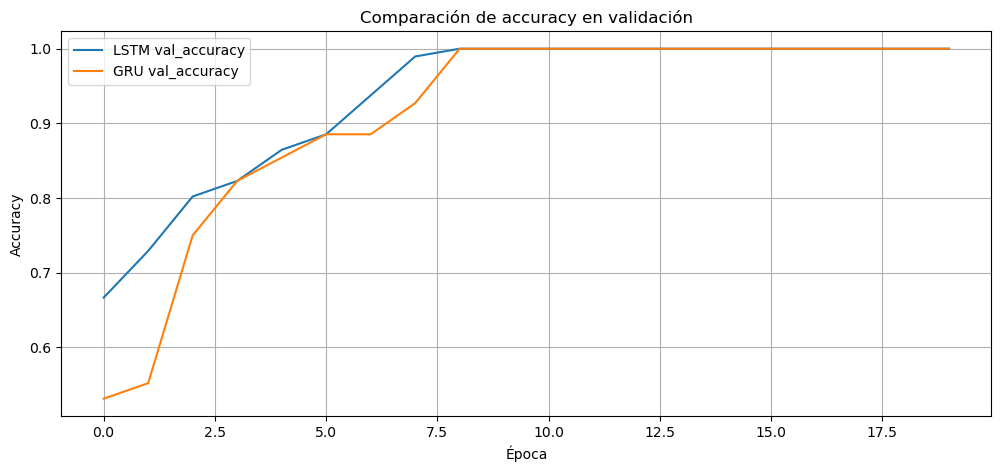

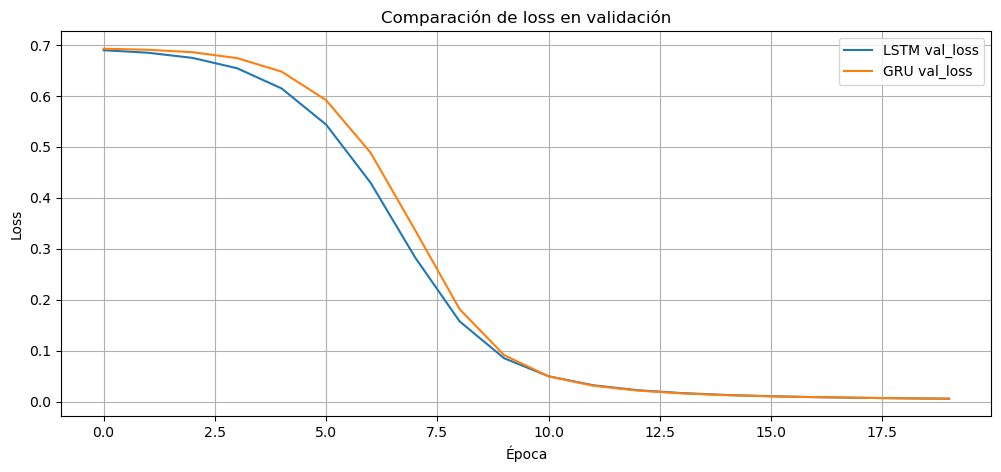

In [41]:
# ==============================================================================
# CELDA 8: GRÁFICAS COMPARATIVAS (LSTM vs GRU)
# ==============================================================================

# --- Gráfica de Precisión (Accuracy) ---
plt.figure(figsize=(12, 5)) # Define el tamaño de la figura (ancho, alto)

# Graficamos la métrica de precisión en el conjunto de validación para ambos modelos
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM val_accuracy")
plt.plot(hist_gru.history["val_accuracy"], label="GRU val_accuracy")

# Configuración estética de la gráfica de Accuracy
plt.title("Comparación de accuracy en validación")
plt.xlabel("Época")      # Eje X representa las iteraciones del entrenamiento
plt.ylabel("Accuracy")   # Eje Y representa el porcentaje de acierto
plt.legend()             # Muestra la leyenda para identificar cada línea
plt.grid(True)           # Añade una cuadrícula para facilitar la lectura
plt.show()               # Despliega la gráfica

# --- Gráfica de Pérdida (Loss) ---
plt.figure(figsize=(12, 5))

# Graficamos la función de pérdida en el conjunto de validación
# Esto ayuda a identificar si hay sobreajuste (overfitting) o convergencia lenta
plt.plot(hist_lstm.history["val_loss"], label="LSTM val_loss")
plt.plot(hist_gru.history["val_loss"], label="GRU val_loss")

# Configuración estética de la gráfica de Loss
plt.title("Comparación de loss en validación")
plt.xlabel("Época")
plt.ylabel("Loss")       # Un valor menor suele indicar un mejor aprendizaje
plt.legend()
plt.grid(True)
plt.show()

### Evaluación final en test

In [43]:
# Se evalúa el modelo LSTM con el conjunto de prueba (X_test_pad y y_test)
# verbose=0 evita que se imprima la barra de progreso, manteniendo limpia la salida
resultado_lstm = modelo_lstm.evaluate(X_test_pad, np.array(y_test), verbose=0)

# Se realiza el mismo proceso para el modelo GRU
resultado_gru = modelo_gru.evaluate(X_test_pad, np.array(y_test), verbose=0)

# --- Impresión de métricas comparativas ---
print("Resultados en test:")

# Mostramos Loss (índice 0) y Accuracy (índice 1) con 4 decimales de precisión
print(f"LSTM -> Loss: {resultado_lstm[0]:.4f} | Accuracy: {resultado_lstm[1]:.4f}")
print(f"GRU  -> Loss: {resultado_gru[0]:.4f} | Accuracy: {resultado_gru[1]:.4f}")

Resultados en test:
LSTM -> Loss: 0.0057 | Accuracy: 1.0000
GRU  -> Loss: 0.0057 | Accuracy: 1.0000


### Frases nuevas

In [47]:
# Puedes agregar aquí nuevas frases para probar generalización.
# Definimos una lista de ejemplos arbitrarios para probar la lógica del modelo
frases_nuevas = [
    "la clase fue excelente durante la sesion",
    "el curso estuvo terrible para el grupo",
    "la explicacion resulto clara en el laboratorio",
    "el sistema parecio inestable segun los resultados",
    "el temario fue excelente para el modulo",
    "la clase fue excelente para los estudiantes"
]

# Transformamos el texto en secuencias numéricas usando el mismo tokenizer de entrenamiento
seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)

# Ajustamos la longitud de las secuencias (padding) para que coincidan con la entrada del modelo
# Es vital usar el mismo 'max_len' y tipo de padding ("post") que en el entrenamiento
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

# Obtenemos las probabilidades de salida (0 a 1) para cada arquitectura
pred_lstm = modelo_lstm.predict(pad_nuevas, verbose=0)
pred_gru = modelo_gru.predict(pad_nuevas, verbose=0)

print("Predicciones sobre frases nuevas:\n")

# Iteramos sobre las frases y sus respectivas predicciones para comparar resultados
for i, frase in enumerate(frases_nuevas):
    print(f"📖 Frase: \"{frase}\"")
    
    # ⚖️ Lógica para asignar emoji según el porcentaje
    # Usamos 0.5 como umbral (threshold)
    emoji_lstm = "✅ (Positivo)" if pred_lstm[i][0] > 0.5 else "❌ (Negativo)"
    emoji_gru  = "✅ (Positivo)" if pred_gru[i][0] > 0.5 else "❌ (Negativo)"
    
    # 📊 Salida formateada con porcentajes y emojis
    # Multiplicamos por 100 para mostrar el porcentaje exacto
    print(f"  🔹 LSTM: {pred_lstm[i][0]}%  -> {emoji_lstm}")
    print(f"  🔸 GRU : {pred_gru[i][0]}%  -> {emoji_gru}")
    print("-" * 70)

Predicciones sobre frases nuevas:

📖 Frase: "la clase fue excelente durante la sesion"
  🔹 LSTM: 0.995357871055603%  -> ✅ (Positivo)
  🔸 GRU : 0.9961237907409668%  -> ✅ (Positivo)
----------------------------------------------------------------------
📖 Frase: "el curso estuvo terrible para el grupo"
  🔹 LSTM: 0.008102658204734325%  -> ❌ (Negativo)
  🔸 GRU : 0.00924739520996809%  -> ❌ (Negativo)
----------------------------------------------------------------------
📖 Frase: "la explicacion resulto clara en el laboratorio"
  🔹 LSTM: 0.9940433502197266%  -> ✅ (Positivo)
  🔸 GRU : 0.996442437171936%  -> ✅ (Positivo)
----------------------------------------------------------------------
📖 Frase: "el sistema parecio inestable segun los resultados"
  🔹 LSTM: 0.368156760931015%  -> ❌ (Negativo)
  🔸 GRU : 0.549295961856842%  -> ✅ (Positivo)
----------------------------------------------------------------------
📖 Frase: "el temario fue excelente para el modulo"
  🔹 LSTM: 0.9955018758773804%  -> 

## BLOQUE B: INTRODUCCIÓN A MODELOS DE LENGUAJE

Construye un mini dataset con ventana deslizante para predecir la siguiente palabra.

Deberas modificar al menos $5$ elementos:
- Corpus
- Tamaño de ventana
- Prompts
- Número de épocas

<code> Corpus: </code>:

1. "el modelo de lenguaje predice la siguiente palabra" -> "el descenso de gradiente optimiza los pesos de la red neuronal"
2. "la salida softmax produce probabilidades" -> "la funcion de activacion softmax produce una distribucion de probabilidades"
3. "el dropout desactiva aleatoriamente neuronas durante el entrenamiento" ->"el siguiente token depende del contexto"
4. "la inteligencia artificial aprende patrones para tomar decisiones" -> "la inteligencia artificial aprende patrones"
5. "las redes neuronales procesan secuencias de datos en capas" -> "las redes neuronales procesan secuencias"

<code> Número de épocas </code>
1. $150$ -> $300$

### Definición y preparación del corpus

In [93]:

# Definimos una lista de strings que servirá como base de datos (Corpus).
# En NLP, el 'corpus' es el conjunto de textos que el modelo usará para  
# extraer representaciones numéricas (vectores) y aprender gramática.
corpus = [
    "la inteligencia artificial aprende patrones para tomar decisiones", #"la inteligencia artificial aprende patrones",
    "las redes neuronales procesan secuencias de datos en capas",#las redes neuronales procesan secuencias",
    "las gru simplifican la memoria recurrente",     
    "las lstm controlan el flujo de informacion",    
    "el dropout desactiva aleatoriamente neuronas durante el entrenamiento",#"el siguiente token depende del contexto",        
    "la funcion de activacion softmax produce una distribucion de probabilidades", #"la salida softmax produce probabilidades",     
    "el descenso de gradiente optimiza los pesos de la red neuronal" #"el modelo de lenguaje predice la siguiente palabra"
]

# Despliegue visual de los datos cargados
# Esta etapa es vital para la limpieza de datos (Data Cleaning); 
# aquí verificaríamos si hay caracteres especiales o errores tipográficos.
print("Corpus de ejemplo:")

for frase in corpus:
    # Iteramos sobre el corpus para inspeccionar la estructura de los datos.
    # En un flujo real, aquí aplicaríamos .lower() o eliminaríamos puntuación.
    print("-", frase)

Corpus de ejemplo:
- la inteligencia artificial aprende patrones para tomar decisiones
- las redes neuronales procesan secuencias de datos en capas
- las gru simplifican la memoria recurrente
- las lstm controlan el flujo de informacion
- el dropout desactiva aleatoriamente neuronas durante el entrenamiento
- la funcion de activacion softmax produce una distribucion de probabilidades
- el descenso de gradiente optimiza los pesos de la red neuronal


### Tokenización del corpus

In [95]:
# 1. Inicializamos el Tokenizer: Asocia cada palabra única con un índice entero.
tokenizer_lm = Tokenizer()

# 2. Construcción del índice: El modelo escanea el corpus y crea el diccionario de mapeo.
tokenizer_lm.fit_on_texts(corpus)

In [97]:
# 3. Tamaño del vocabulario: Sumamos 1 para considerar el índice 0 (usado para el padding).
total_words = len(tokenizer_lm.word_index) + 1
total_words

47

In [99]:
# Guardamos el mapeo de palabra a índice para referencia o depuración.
word_index_lm = tokenizer_lm.word_index

# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index_lm.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

Índice     | Palabra             
-----------------------------------
1          | de                  
2          | la                  
3          | el                  
4          | las                 
5          | inteligencia        
6          | artificial          
7          | aprende             
8          | patrones            
9          | para                
10         | tomar               
11         | decisiones          
12         | redes               
13         | neuronales          
14         | procesan            
15         | secuencias          
16         | datos               
17         | en                  
18         | capas               
19         | gru                 
20         | simplifican         
21         | memoria             
22         | recurrente          
23         | lstm                
24         | controlan           
25         | flujo               
-----------------------------------


### Ventana deslizante

In [101]:
# 4. Generación de secuencias de entrenamiento (Ventana Deslizante):
input_sequences = []
for frase in corpus:
    # Convertimos el texto de la frase en una lista de números según el vocabulario
    token_list = tokenizer_lm.texts_to_sequences([frase])[0]
    
    # Creamos sub-secuencias incrementales (N-gramas) para que el modelo aprenda contexto.
    # Ejemplo: "la inteligencia artificial" -> [la, inteligencia], [la, inteligencia, artificial]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)
input_sequences

[[2, 5],
 [2, 5, 6],
 [2, 5, 6, 7],
 [2, 5, 6, 7, 8],
 [2, 5, 6, 7, 8, 9],
 [2, 5, 6, 7, 8, 9, 10],
 [2, 5, 6, 7, 8, 9, 10, 11],
 [4, 12],
 [4, 12, 13],
 [4, 12, 13, 14],
 [4, 12, 13, 14, 15],
 [4, 12, 13, 14, 15, 1],
 [4, 12, 13, 14, 15, 1, 16],
 [4, 12, 13, 14, 15, 1, 16, 17],
 [4, 12, 13, 14, 15, 1, 16, 17, 18],
 [4, 19],
 [4, 19, 20],
 [4, 19, 20, 2],
 [4, 19, 20, 2, 21],
 [4, 19, 20, 2, 21, 22],
 [4, 23],
 [4, 23, 24],
 [4, 23, 24, 3],
 [4, 23, 24, 3, 25],
 [4, 23, 24, 3, 25, 1],
 [4, 23, 24, 3, 25, 1, 26],
 [3, 27],
 [3, 27, 28],
 [3, 27, 28, 29],
 [3, 27, 28, 29, 30],
 [3, 27, 28, 29, 30, 31],
 [3, 27, 28, 29, 30, 31, 3],
 [3, 27, 28, 29, 30, 31, 3, 32],
 [2, 33],
 [2, 33, 1],
 [2, 33, 1, 34],
 [2, 33, 1, 34, 35],
 [2, 33, 1, 34, 35, 36],
 [2, 33, 1, 34, 35, 36, 37],
 [2, 33, 1, 34, 35, 36, 37, 38],
 [2, 33, 1, 34, 35, 36, 37, 38, 1],
 [2, 33, 1, 34, 35, 36, 37, 38, 1, 39],
 [3, 40],
 [3, 40, 1],
 [3, 40, 1, 41],
 [3, 40, 1, 41, 42],
 [3, 40, 1, 41, 42, 43],
 [3, 40, 1, 41, 42, 

### Pre Padding

In [103]:
# 5. Normalización de longitud (Padding):
# Buscamos la frase más larga para que todas las entradas tengan el mismo tamaño.
max_sequence_len = max(len(seq) for seq in input_sequences)
max_sequence_len

11

In [105]:
print("--- ANTES DEL PRE-PADDING (Longitudes variables) ---")
for i in range(5):
    print(f"Secuencia {i}: {input_sequences[i]}")

--- ANTES DEL PRE-PADDING (Longitudes variables) ---
Secuencia 0: [2, 5]
Secuencia 1: [2, 5, 6]
Secuencia 2: [2, 5, 6, 7]
Secuencia 3: [2, 5, 6, 7, 8]
Secuencia 4: [2, 5, 6, 7, 8, 9]


In [107]:
# Aplicamos "pre-padding": rellenamos con ceros a la izquierda para que la red
# neuronal reciba vectores de tamaño uniforme sin perder el orden final.
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding="pre")
)

In [109]:
print("--- DESPUÉS DEL PRE-PADDING (Longitudes variables) ---")
for i in range(5):
    print(f"Secuencia {i}: {input_sequences[i]}")

--- DESPUÉS DEL PRE-PADDING (Longitudes variables) ---
Secuencia 0: [0 0 0 0 0 0 0 0 0 2 5]
Secuencia 1: [0 0 0 0 0 0 0 0 2 5 6]
Secuencia 2: [0 0 0 0 0 0 0 2 5 6 7]
Secuencia 3: [0 0 0 0 0 0 2 5 6 7 8]
Secuencia 4: [0 0 0 0 0 2 5 6 7 8 9]


### División de datos 

In [111]:
# X_lm: Todas las palabras excepto la última (el historial que el modelo ve).
X_lm = input_sequences[:, :-1]
X_lm[:5]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 2],
       [0, 0, 0, 0, 0, 0, 0, 0, 2, 5],
       [0, 0, 0, 0, 0, 0, 0, 2, 5, 6],
       [0, 0, 0, 0, 0, 0, 2, 5, 6, 7],
       [0, 0, 0, 0, 0, 2, 5, 6, 7, 8]])

In [113]:
# y_lm: La última palabra de la secuencia (lo que el modelo debe intentar predecir).
y_lm = input_sequences[:, -1]
y_lm[:5]

array([5, 6, 7, 8, 9])

In [115]:
y_lm[0]

5

In [117]:
# --- Visualización de las primeras 5 muestras ---

print(" INSPECCIÓN DE DATOS (X e y):")
print("-" * 50)

for i in range(5):
    print(f"Muestra {i+1}:")
    print(f"  Entrada (X) - El 'Pasado': {X_lm[i]}")
    print(f"  Salida  (y) - El 'Futuro': {y_lm[i]}")
    print("-" * 30)

 INSPECCIÓN DE DATOS (X e y):
--------------------------------------------------
Muestra 1:
  Entrada (X) - El 'Pasado': [0 0 0 0 0 0 0 0 0 2]
  Salida  (y) - El 'Futuro': 5
------------------------------
Muestra 2:
  Entrada (X) - El 'Pasado': [0 0 0 0 0 0 0 0 2 5]
  Salida  (y) - El 'Futuro': 6
------------------------------
Muestra 3:
  Entrada (X) - El 'Pasado': [0 0 0 0 0 0 0 2 5 6]
  Salida  (y) - El 'Futuro': 7
------------------------------
Muestra 4:
  Entrada (X) - El 'Pasado': [0 0 0 0 0 0 2 5 6 7]
  Salida  (y) - El 'Futuro': 8
------------------------------
Muestra 5:
  Entrada (X) - El 'Pasado': [0 0 0 0 0 2 5 6 7 8]
  Salida  (y) - El 'Futuro': 9
------------------------------


In [119]:
# 7. Vectorización de etiquetas (One-Hot Encoding):
# Convertimos el índice del target en un vector binario para la capa de salida Softmax.
y_lm = to_categorical(y_lm, num_classes=total_words)
y_lm

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [121]:
# Diagnóstico de dimensiones
print("Forma de X_lm (Muestras, Longitud):", X_lm.shape)
print("Forma de y_lm (Muestras, Vocabulario):", y_lm.shape)
print("Vocabulario total (Nº de clases):", total_words)

Forma de X_lm (Muestras, Longitud): (52, 10)
Forma de y_lm (Muestras, Vocabulario): (52, 47)
Vocabulario total (Nº de clases): 47


### Modelo GRU

<img src="https://github.com/DataScienceUB/DeepLearningMaster2019/blob/master/images/gru.png?raw=1" alt="Source: http://colah.github.io/posts/2015-08-Understanding-LSTMs/" style="width: 300px;"> 

In [123]:
# ==============================================================================
#  ARQUITECTURA DEL MODELO DE LENGUAJE (RNN - GRU)
# ==============================================================================

modelo_lm = Sequential()

# 1. Capa de Entrada:
# Definimos el tamaño que recibirá el modelo. Es la longitud máxima menos 1
# (porque quitamos el target para que sea el 'X_lm').
modelo_lm.add(Input(shape=(max_sequence_len - 1,)))

# 2. Capa de Embedding:
# ¡Magia pura! Convierte números simples en vectores densos de 32 dimensiones.
# Aquí las palabras con significados similares empiezan a agruparse en el espacio.
modelo_lm.add(Embedding(input_dim=total_words, output_dim=32))

# 3. Capa GRU:
# La "memoria" del modelo. A diferencia de una red simple, la GRU decide qué
# información del historial mantener y cuál descartar para predecir el futuro.
modelo_lm.add(GRU(32))

# 4. Capa de Salida (Dense):
# Tiene tantas neuronas como palabras en el vocabulario (total_words).
# La activación "softmax" convierte la salida en un ranking de probabilidades.
modelo_lm.add(Dense(total_words, activation="softmax"))

# 5. Compilación:
# - Optimizer (Adam): El algoritmo que ajusta los pesos para reducir el error.
# - Loss (Categorical Crossentropy): La función que castiga al modelo si falla la palabra.
# - Metrics: Queremos saber qué tan preciso (Accuracy) es prediciendo el token.
modelo_lm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Visualización de la estructura y número de parámetros entrenables
modelo_lm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 10, 32)              │           1,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           6,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 47)                  │           1,551 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,391 (36.68 KB)

 Trainable params: 9,391 (36.68 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo de lenguaje (GRU)

In [125]:
# Iniciamos el proceso de aprendizaje (fit)
hist_lm = modelo_lm.fit(
    X_lm,           # El historial de palabras 
    y_lm,           # El siguiente token real 
    epochs=300,     # El modelo pasará 150 veces por todo el corpus para aprender
    verbose=0       # 0 = Silencioso. No muestra la barra de progreso por cada época
)

# El objeto 'hist_lm' ahora guarda la evolución de la pérdida (loss) y precisión (accuracy)
print("Entrenamiento del modelo de lenguaje completado.")

Entrenamiento del modelo de lenguaje completado.


### Función simple de generación (Inferencia)

In [126]:

def generar_texto(modelo, tokenizer, seed_text, max_sequence_len, n_palabras=5):
    """
    modelo: El modelo GRU entrenado.
    seed_text: La frase inicial (semilla) para empezar la predicción.
    max_sequence_len: La longitud de secuencia que el modelo espera.
    n_palabras: Cuántas palabras nuevas queremos que genere.
    """
    
    # 1. Bucle de autoregresión: Generamos una palabra a la vez
    for _ in range(n_palabras):
        
        # 2. Preprocesamiento de la semilla:
        # Convertimos las palabras actuales en los números que el modelo entiende.
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # 3. Ajuste de longitud (Padding):
        # Aseguramos que la entrada tenga el tamaño exacto (max - 1) que definimos en la arquitectura.
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding="pre")

        # 4. Predicción:
        # El modelo devuelve un vector de probabilidades (Softmax) para todo el vocabulario.
        predicted = modelo.predict(token_list, verbose=0)

        # 5. Selección del ganador:
        # Tomamos el índice de la palabra que obtuvo la probabilidad más alta (Greedy Search).
        predicted_index = np.argmax(predicted, axis=1)[0]

        # 6. Des-tokenización (Traducción inversa):
        # Buscamos en nuestro diccionario qué palabra humana corresponde a ese número.
        output_word = ""
        for palabra, indice in tokenizer.word_index.items():
            if indice == predicted_index:
                output_word = palabra
                break

        # 7. Control de errores: Si el índice no existe en el vocabulario, paramos.
        if output_word == "":
            break

        # 8. Actualización de la semilla:
        # Concatenamos la palabra generada para que sea parte de la entrada en la siguiente iteración.
        seed_text += " " + output_word

    return seed_text

### Probar el modelo de lenguaje

In [145]:
# ==============================================================================
# CELDA 16: PRUEBAS DE GENERACIÓN (VALIDACIÓN DEL MODELO)
# ==============================================================================

# 1. Definimos una lista de "semillas" o prompts iniciales.
# Estas palabras deben existir en el vocabulario para que el modelo tenga un punto de partida.
prompts = [
    "la inteligencia",
    "la función de activacion",
    "el descenso",
    "el dropout"
]

# 2. Iteramos sobre cada prompt para ver cómo responde la red neuronal
for prompt in prompts:
    # Llamamos a nuestra función de generación definida anteriormente.
    # Pedimos al modelo que genere las siguientes 5 palabras para cada semilla.
    generado = generar_texto(modelo_lm, tokenizer_lm, prompt, max_sequence_len, n_palabras=6)
    
    # 3. Despliegue de resultados:
    print("Prompt:", prompt)          # Lo que nosotros escribimos
    print("Texto generado:", generado) # Lo que el modelo completó
    print("-" * 70)                    # Separador visual para mayor claridad

Prompt: la inteligencia
Texto generado: la inteligencia artificial aprende patrones para tomar decisiones
----------------------------------------------------------------------
Prompt: la función de activacion
Texto generado: la función de activacion softmax produce una distribucion de probabilidades
----------------------------------------------------------------------
Prompt: el descenso
Texto generado: el descenso de gradiente optimiza los pesos de
----------------------------------------------------------------------
Prompt: el dropout
Texto generado: el dropout desactiva aleatoriamente neuronas durante el entrenamiento
----------------------------------------------------------------------


## Conclusión

 1. **¿Qué diferencias viste entre LSTM y GRU?** La principal diferencia es la complejidad, pero en cuanto al bloque A, la LSTM en es mejor, ya que desde la época $0$ se alcanza a ver un mejor rendimiento, siendo la época $8$ en donde ambas redes alcanzan el mismo acurracy ($1$)
    
 3. **¿La GRU logró rendimiento parecido a la LSTM?** Generalmente sí, pero en el Bloque A, suele ser muy similar a la LSTM.
    
 4. **¿Qué hace la ventana deslizante?** Es la técnica de aumento de datos que fragmenta una oración en múltiples  ejemplos de entrenamiento. 

5. **¿Qué función cumple softmax en el modelo de lenguaje?**
Toma los valores de la última capa  y los convierte en una distribución que suma 1 (100%), con esto permite interpretar la salida como la probabilidad relativa de cada palabra (dentro del vocabulario) para ser el siguiente token.

6. **¿En qué cambia el problema cuando pasamos de clasificar a generar?**
En clasificación (ej. análisis de sentimiento), el modelo da una respuesta única.  En generación, el problema es "autoregresivo": la salida del modelo se convierte  en su propia entrada para el siguiente paso, creando una cadena de dependencias.